# Trading Strategy Project - Developing Alpha Signals from Alternative Data

We define $r_{i,t+1}$ as the future return of asset $i$. Let $X_{i,t}$ be an alpha signal. We say that such a signal is significant if 
$$\mathbb E[r_{i,t+1}] \neq \mathbb E[r_{i,t+1} ~|~ X_{i,t}].$$

Our goal is to generate significant alpha signals from alternative data, such as reddit posts, foot traffic, X, etc.

Before we attempt to generate alpha signals from alternative data, we will try simple trading strategies simply based on daily returns, moving averages, and volatility. We will use models such as RandomForestRegressor and XGBoost, as well as a Cross-Sectional Ranking Strategy. 

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [2]:
df = yf.download("AAPL", start="2025-01-02", end="2026-05-07")

close = df["Close"].squeeze()
df["returns"] = close.pct_change()
df["ma_20"] = close.rolling(20).mean()
df["ma_gap"] = close / df["ma_20"] - 1
df["vol_20"] = df["returns"].rolling(20).std()
df["target"] = df["returns"].shift(-1)

df = df.dropna()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,returns,ma_20,ma_gap,vol_20,target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2025-02-03,226.771225,230.570478,224.473778,228.740479,73063300,-0.033856,232.524787,-0.024744,0.019796,0.021008
2025-02-04,231.535202,231.863411,225.418606,226.015352,45067300,0.021008,231.999655,-0.002002,0.020522,-0.001418
2025-02-05,231.206985,231.405896,227.029807,227.288389,39620300,-0.001418,231.376559,-0.000733,0.020420,0.003226
2025-02-06,231.952911,232.529762,229.178061,230.033389,29925300,0.003226,230.929500,0.004432,0.020343,-0.023969
2025-02-07,226.393280,232.728667,226.025280,231.336279,39707200,-0.023969,230.180094,-0.016452,0.020916,0.001187


<Axes: title={'center': 'AAPL Price'}, xlabel='Date'>

<Figure size 640x480 with 0 Axes>

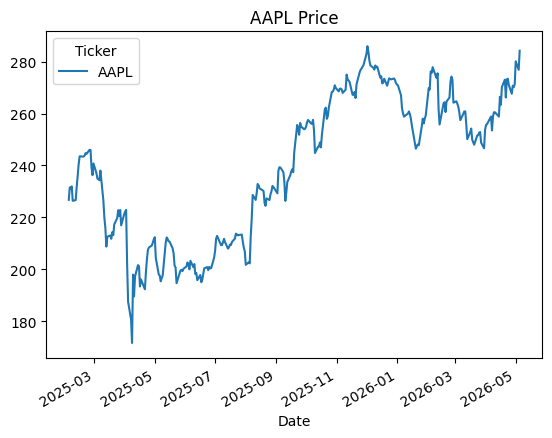

In [16]:
plt.figure()
df["Close"].plot(title="AAPL Price")

<Axes: title={'center': 'AAPL Daily Returns'}, xlabel='Date'>

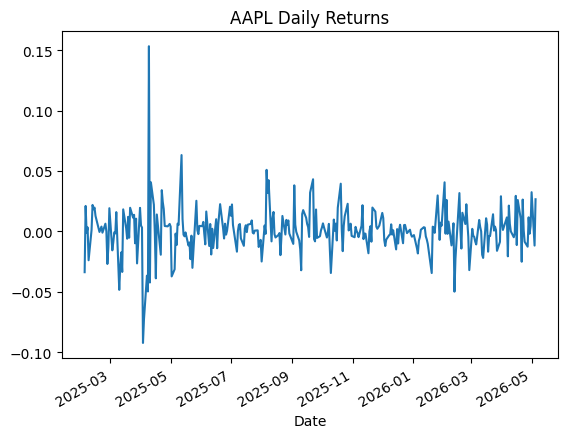

In [17]:
plt.figure()
df["returns"].plot(title="AAPL Daily Returns")

Let's come up with a way to predict tomorrow's stock price.

In [18]:
features = ["returns", "ma_gap", "vol_20", "ma_20"]

X = df[features]
y = df["target"]

split = int(0.8 * len(df))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

corr = np.corrcoef(y_pred, y_test)[0,1]
print(corr)

0.04556920937525926


No correlation, we need to come up with a new way to generate signals.

In [24]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]

data = yf.download(tickers, start="2025-01-01")["Close"]

returns = data.pct_change()
momentum_5 = data.pct_change(5)
momentum_20 = data.pct_change(20)
vol_20 = returns.rolling(20).std()
ma_20 = data.rolling(20).mean()
ma_gap = data / ma_20 - 1
target = returns.shift(-1)

df = []

for ticker in tickers:
    tmp = pd.DataFrame({
        "return": returns[ticker],
        "mom_5": momentum_5[ticker],
        "mom_20": momentum_20[ticker],
        "vol_20": vol_20[ticker],
        "ma_gap": ma_gap[ticker],
        "target": target[ticker]
    })

    tmp["ticker"] = ticker
    df.append(tmp)

df = pd.concat(df)
df = df.dropna()

df[df["ticker"] == "MSFT"].head()

[*********************100%***********************]  5 of 5 completed


,return,mom_5,mom_20,vol_20,ma_gap,target,ticker
Date,,,,,,,
2025-02-03,-0.009974,-0.054400,-0.018300,0.021148,-0.039950,0.003529,MSFT
2025-02-04,0.003529,-0.077885,-0.025936,0.020983,-0.035325,0.002231,MSFT
2025-02-05,0.002231,-0.065652,-0.034031,0.020820,-0.031524,0.006121,MSFT
2025-02-06,0.006121,0.002000,-0.015508,0.020709,-0.024847,-0.014598,MSFT
2025-02-07,-0.014598,-0.012793,-0.034883,0.020891,-0.037410,0.006028,MSFT


# Random Forest Regression Strategy (Baseline Alpha Model)

## Overview
This strategy attempts to predict **next-day stock returns directly** using simple technical indicators. It is a supervised regression problem:

$$
X_{i,t} \rightarrow r_{i,t+1}
$$

Each stock is treated independently, and predictions are used to generate trading signals.

---

## Features (Inputs)

We use standard technical indicators:

- **return**: daily return \( r_{i,t} \)
- **mom_5**: 5-day momentum (short-term trend)
- **mom_20**: 20-day momentum (medium-term trend)
- **vol_20**: 20-day rolling volatility (risk proxy)
- **ma_gap**: deviation from moving average (mean reversion signal)

---

## Target

- **target = next-day return**
\[
r_{i,t+1}
\]

---

## Model

We use:
- Random Forest Regressor

This model captures nonlinear interactions between features.

---

## Trading Rule

- If predicted return > 0 → go **long**
- If predicted return < 0 → go **short**

---

## Strategy Return

$$
R_t = \text{signal}_t \cdot r_{t+1}
$$

---

## Intuition

Buy stocks the model expects to go up tomorrow and short those expected to go down

---

## Limitation

- No cross-sectional comparison between stocks
- Highly noisy at daily frequency
- Weak predictive signal in isolation

Prediction correlation: 0.12489500780158674
MSE: 0.0006158200846853086


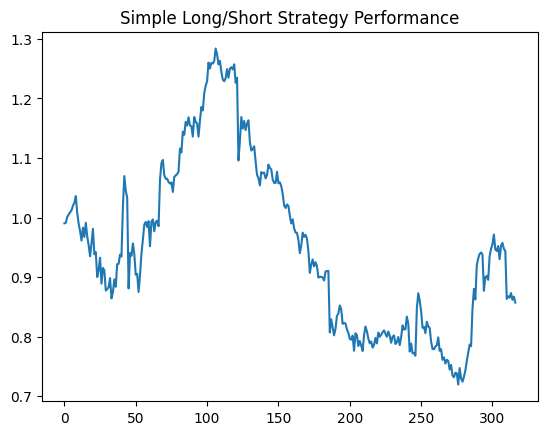

In [25]:
features = ["return", "mom_5", "mom_20", "vol_20", "ma_gap"]

X = df[features]
y = df["target"]

# ----------------------------
# 1. TIME SPLIT
# ----------------------------

split = int(0.8 * len(df))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ----------------------------
# 2. MODEL
# ----------------------------

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 3. PREDICTIONS
# ----------------------------

y_pred = model.predict(X_test)

# ----------------------------
# 4. EVALUATION (SIGNAL QUALITY)
# ----------------------------

corr = np.corrcoef(y_pred, y_test)[0, 1]
print("Prediction correlation:", corr)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# ----------------------------
# 5. SIMPLE TRADING STRATEGY
# ----------------------------

signal = np.where(y_pred > 0, 1, -1)
strategy_returns = signal * y_test.values

cumulative = np.cumprod(1 + strategy_returns)

plt.plot(cumulative)
plt.title("Simple Long/Short Strategy Performance")
plt.show()

# XGBoost Regression Strategy (Nonlinear Alpha Model)

## Overview
This strategy improves upon the baseline by using a more powerful nonlinear model to predict next-day returns:

$$
X_{i,t} \rightarrow r_{i,t+1}
$$

It captures nonlinear relationships and interactions between features.

---

## Features

Same as baseline:
- return
- mom_5
- mom_20
- vol_20
- ma_gap

---

## Model

We use:

:contentReference[oaicite:0]{index=0}

Key idea:
- Sequential tree boosting
- Each tree corrects errors of previous ones
- Captures nonlinear patterns in financial data

---

## Trading Rule

- If predicted return > 0 → long
- If predicted return < 0 → short

---

## Intuition

Instead of simple averages, the model learns complex conditional rules like:
- momentum works only when volatility is low
- mean reversion depends on regime”

---

## Advantage over Random Forest

- Better handling of weak signals
- Captures nonlinear structure
- Typically more stable predictions

---

## Limitation

- Still predicts absolute returns
- Does not exploit cross-sectional relationships

[*********************100%***********************]  5 of 5 completed


Prediction correlation: -0.0361523390818212


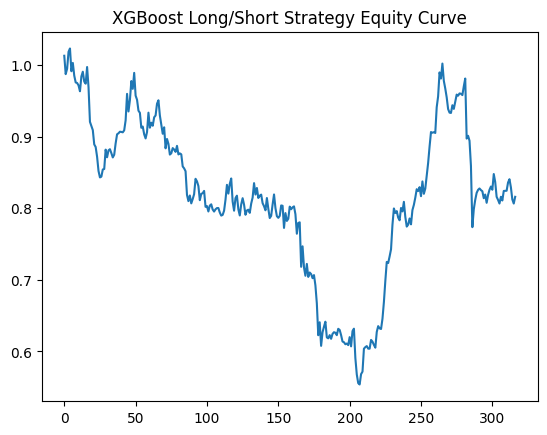

In [22]:
# ----------------------------
# 1. DATA
# ----------------------------

tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]

data = yf.download(tickers, start="2025-01-01")["Close"]

returns = data.pct_change()
momentum_5 = data.pct_change(5)
momentum_20 = data.pct_change(20)
vol_20 = returns.rolling(20).std()
ma_20 = data.rolling(20).mean()
ma_gap = data / ma_20 - 1

# predict next-day return
target = returns.shift(-1)

# ----------------------------
# 2. BUILD PANEL DATASET
# ----------------------------

df_list = []

for t in tickers:
    tmp = pd.DataFrame({
        "return": returns[t],
        "mom_5": momentum_5[t],
        "mom_20": momentum_20[t],
        "vol_20": vol_20[t],
        "ma_gap": ma_gap[t],
        "target": target[t]
    })
    
    tmp["ticker"] = t
    df_list.append(tmp)

df = pd.concat(df_list).dropna()
df = df.sort_index()

# ----------------------------
# 3. FEATURES / TARGET
# ----------------------------

features = ["return", "mom_5", "mom_20", "vol_20", "ma_gap"]

X = df[features]
y = df["target"]

# ----------------------------
# 4. TIME SPLIT
# ----------------------------

split = int(0.8 * len(df))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ----------------------------
# 5. XGBOOST MODEL
# ----------------------------

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 6. PREDICTIONS
# ----------------------------

y_pred = model.predict(X_test)

# ----------------------------
# 7. EVALUATION
# ----------------------------

corr = np.corrcoef(y_pred, y_test)[0, 1]
print("Prediction correlation:", corr)

# ----------------------------
# 8. TRADING STRATEGY
# ----------------------------

signal = np.where(y_pred > 0, 1, -1)

strategy_returns = signal * y_test.values

# cumulative performance
cumulative = np.cumprod(1 + strategy_returns)

# ----------------------------
# 9. PLOT EQUITY CURVE
# ----------------------------

plt.figure()
plt.plot(cumulative)
plt.title("XGBoost Long/Short Strategy Equity Curve")
plt.show()

# Cross-Sectional Ranking Strategy 

## Overview
Instead of predicting absolute returns, this strategy predicts **relative performance across stocks** each day.

The model is used to rank stocks cross-sectionally:

$$
f(X_{i,t}) \rightarrow \text{ranking of stocks at time } t
$$

---

## Features

Same feature set:
- return
- mom_5
- mom_20
- vol_20
- ma_gap

---

## Key Idea

Each day:
- We compare all stocks to each other
- We do NOT care about exact return values
- We care about **who will outperform vs underperform**

---

## Trading Rule

Each day:

- 🟢 Top-ranked stocks → LONG
- 🔴 Bottom-ranked stocks → SHORT
- 🟡 Middle stocks → ignored

---

## Strategy Return

Portfolio return is:

$$
R_t = \text{average return of longs} - \text{average return of shorts}
$$

---

## Intuition

The model is not predicting returns — it is predicting rankings.

This aligns with how real hedge funds build equity long/short strategies.

---

## Why this works better

- Reduces noise from absolute return prediction
- Exploits cross-sectional inefficiencies
- More stable than single-stock prediction

---

## Limitation

- Depends heavily on feature quality
- Requires strong ranking signal (not just prediction accuracy)

[*********************100%***********************]  5 of 5 completed


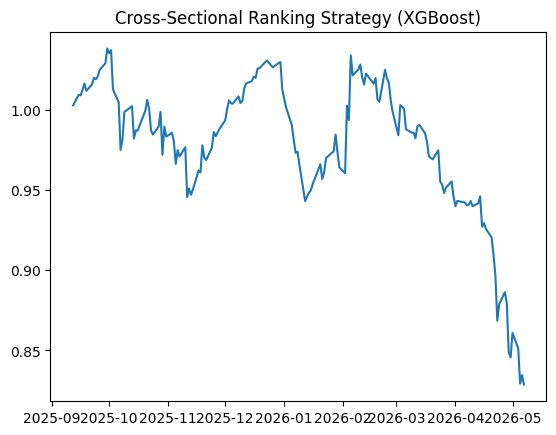

Prediction correlation: -0.025247084344475687


In [30]:
# ----------------------------
# 1. DATA
# ----------------------------

tickers = ["AMD", "MSFT", "AMZN", "GOOGL", "META"]

data = yf.download(tickers, start="2023-01-01")["Close"]

returns = data.pct_change()
momentum_5 = data.pct_change(5)
momentum_20 = data.pct_change(20)
vol_20 = returns.rolling(20).std()
ma_20 = data.rolling(20).mean()
ma_gap = data / ma_20 - 1

target = returns.shift(-1)

# ----------------------------
# 2. BUILD PANEL DATASET
# ----------------------------

df_list = []

for t in tickers:
    tmp = pd.DataFrame({
        "return": returns[t],
        "mom_5": momentum_5[t],
        "mom_20": momentum_20[t],
        "vol_20": vol_20[t],
        "ma_gap": ma_gap[t],
        "target": target[t]
    })
    tmp["ticker"] = t
    df_list.append(tmp)

df = pd.concat(df_list).dropna()
df = df.sort_index()

features = ["return", "mom_5", "mom_20", "vol_20", "ma_gap"]

# ----------------------------
# 3. TIME SPLIT
# ----------------------------

split = int(0.8 * len(df))

train = df.iloc[:split]
test = df.iloc[split:]

X_train, y_train = train[features], train["target"]
X_test = test[features]
y_test = test["target"]

# ----------------------------
# 4. MODEL (XGBOOST)
# ----------------------------

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 5. PREDICTIONS
# ----------------------------

test = test.copy()
test["pred"] = model.predict(X_test)

# ----------------------------
# 6. RANKING STRATEGY
# ----------------------------

# cross-sectional ranking each day
test["rank"] = test.groupby(test.index)["pred"].rank()

# normalize ranks into signals
test["signal"] = test.groupby(test.index)["rank"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# ----------------------------
# 7. STRATEGY RETURNS
# ----------------------------

test["strategy_return"] = test["signal"] * test["target"]

# aggregate across stocks per day
daily_returns = test.groupby(test.index)["strategy_return"].mean()

# cumulative performance
equity_curve = (1 + daily_returns).cumprod()

# ----------------------------
# 8. PLOT
# ----------------------------

plt.figure()
plt.plot(equity_curve)
plt.title("Cross-Sectional Ranking Strategy (XGBoost)")
plt.show()

# ----------------------------
# 9. METRIC: CORRELATION
# ----------------------------

corr = np.corrcoef(test["pred"], test["target"])[0, 1]
print("Prediction correlation:", corr)